In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Generate synthetic data
df = pd.read_csv('power+consumption+of+tetouan+city/Tetuan City power consumption.csv')

df['DateTime'] = pd.to_datetime(df['DateTime'])

# Creating new columns from datetime
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Minute'] = df['DateTime'].dt.minute

df.drop(columns=['DateTime'], inplace=True)

X = df.drop(['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption'], axis=1)
y = df['Zone 1 Power Consumption']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize an empty dictionary to store model predictions
predictions = {}

# 1. Support Vector Machine (SVM)
print('Training SVR:')
svm_model = SVR(kernel='linear')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
predictions['SVM'] = svm_pred

# 2. XGBoost
print('Training XGBoost')
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
predictions['XGBoost'] = xgb_pred

# 3. Linear Regression
print('Training Linear Regression:')
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
predictions['Linear Regression'] = linear_pred

# 4. LSTM
print('Training LSTM:')
# Reshape data for LSTM [samples, time steps, features]
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X_train.shape[1])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test_lstm)
predictions['LSTM'] = lstm_pred.flatten()

print('Training GPR:')
# 5. Gaussian Process Regression (GPR)
gpr_model = GaussianProcessRegressor()
gpr_model.fit(X_train, y_train)
gpr_pred = gpr_model.predict(X_test)
predictions['GPR'] = gpr_pred

# Display performance metrics of each model
for model_name, model_pred in predictions.items():
    print(f"{model_name} MAE: {mean_absolute_error(y_test, model_pred)}")
    print(f"{model_name} R squared: {r2_score(y_test, model_pred)}")


        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   
3  1/1/2017 0:30        6.121      75.0       0.083                  0.091   
4  1/1/2017 0:40        5.921      75.7       0.081                  0.048   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620                16128.87538   
1          0.085               29814.68354                19375.07599   
2          0.100               29128.10127                19006.68693   
3          0.096               28228.86076                18361.09422   
4          0.085               27335.69620                17872.34043   

   Zone 3  Power Consumption  
0                20240.96386  
1                20131.08434  

/Users/zsnatalia/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step
SVM MSE: 18261726.686055988
XGBoost MSE: 1096113.3239723463
Linear Regression MSE: 17950795.696100276
LSTM MSE: 17717506.353585772
GPR MSE: 857078535.8496604


In [24]:
from sklearn.metrics import mean_absolute_error, r2_score
for model_name, model_pred in predictions.items():
    print(f"{model_name} MAE: {mean_absolute_error(y_test, model_pred)}")
    print(f"{model_name} R squared: {r2_score(y_test, model_pred)}")

SVM MAE: 3359.7163167791123
SVM R squared: 0.638341447713827
XGBoost MAE: 758.5780256803523
XGBoost R squared: 0.9782923726378998
Linear Regression MAE: 3367.499538825576
Linear Regression R squared: 0.6444991815153165
LSTM MAE: 3313.0457249081933
LSTM R squared: 0.6491192860283257
GPR MAE: 27181.668851096143
GPR R squared: -15.973739000684041


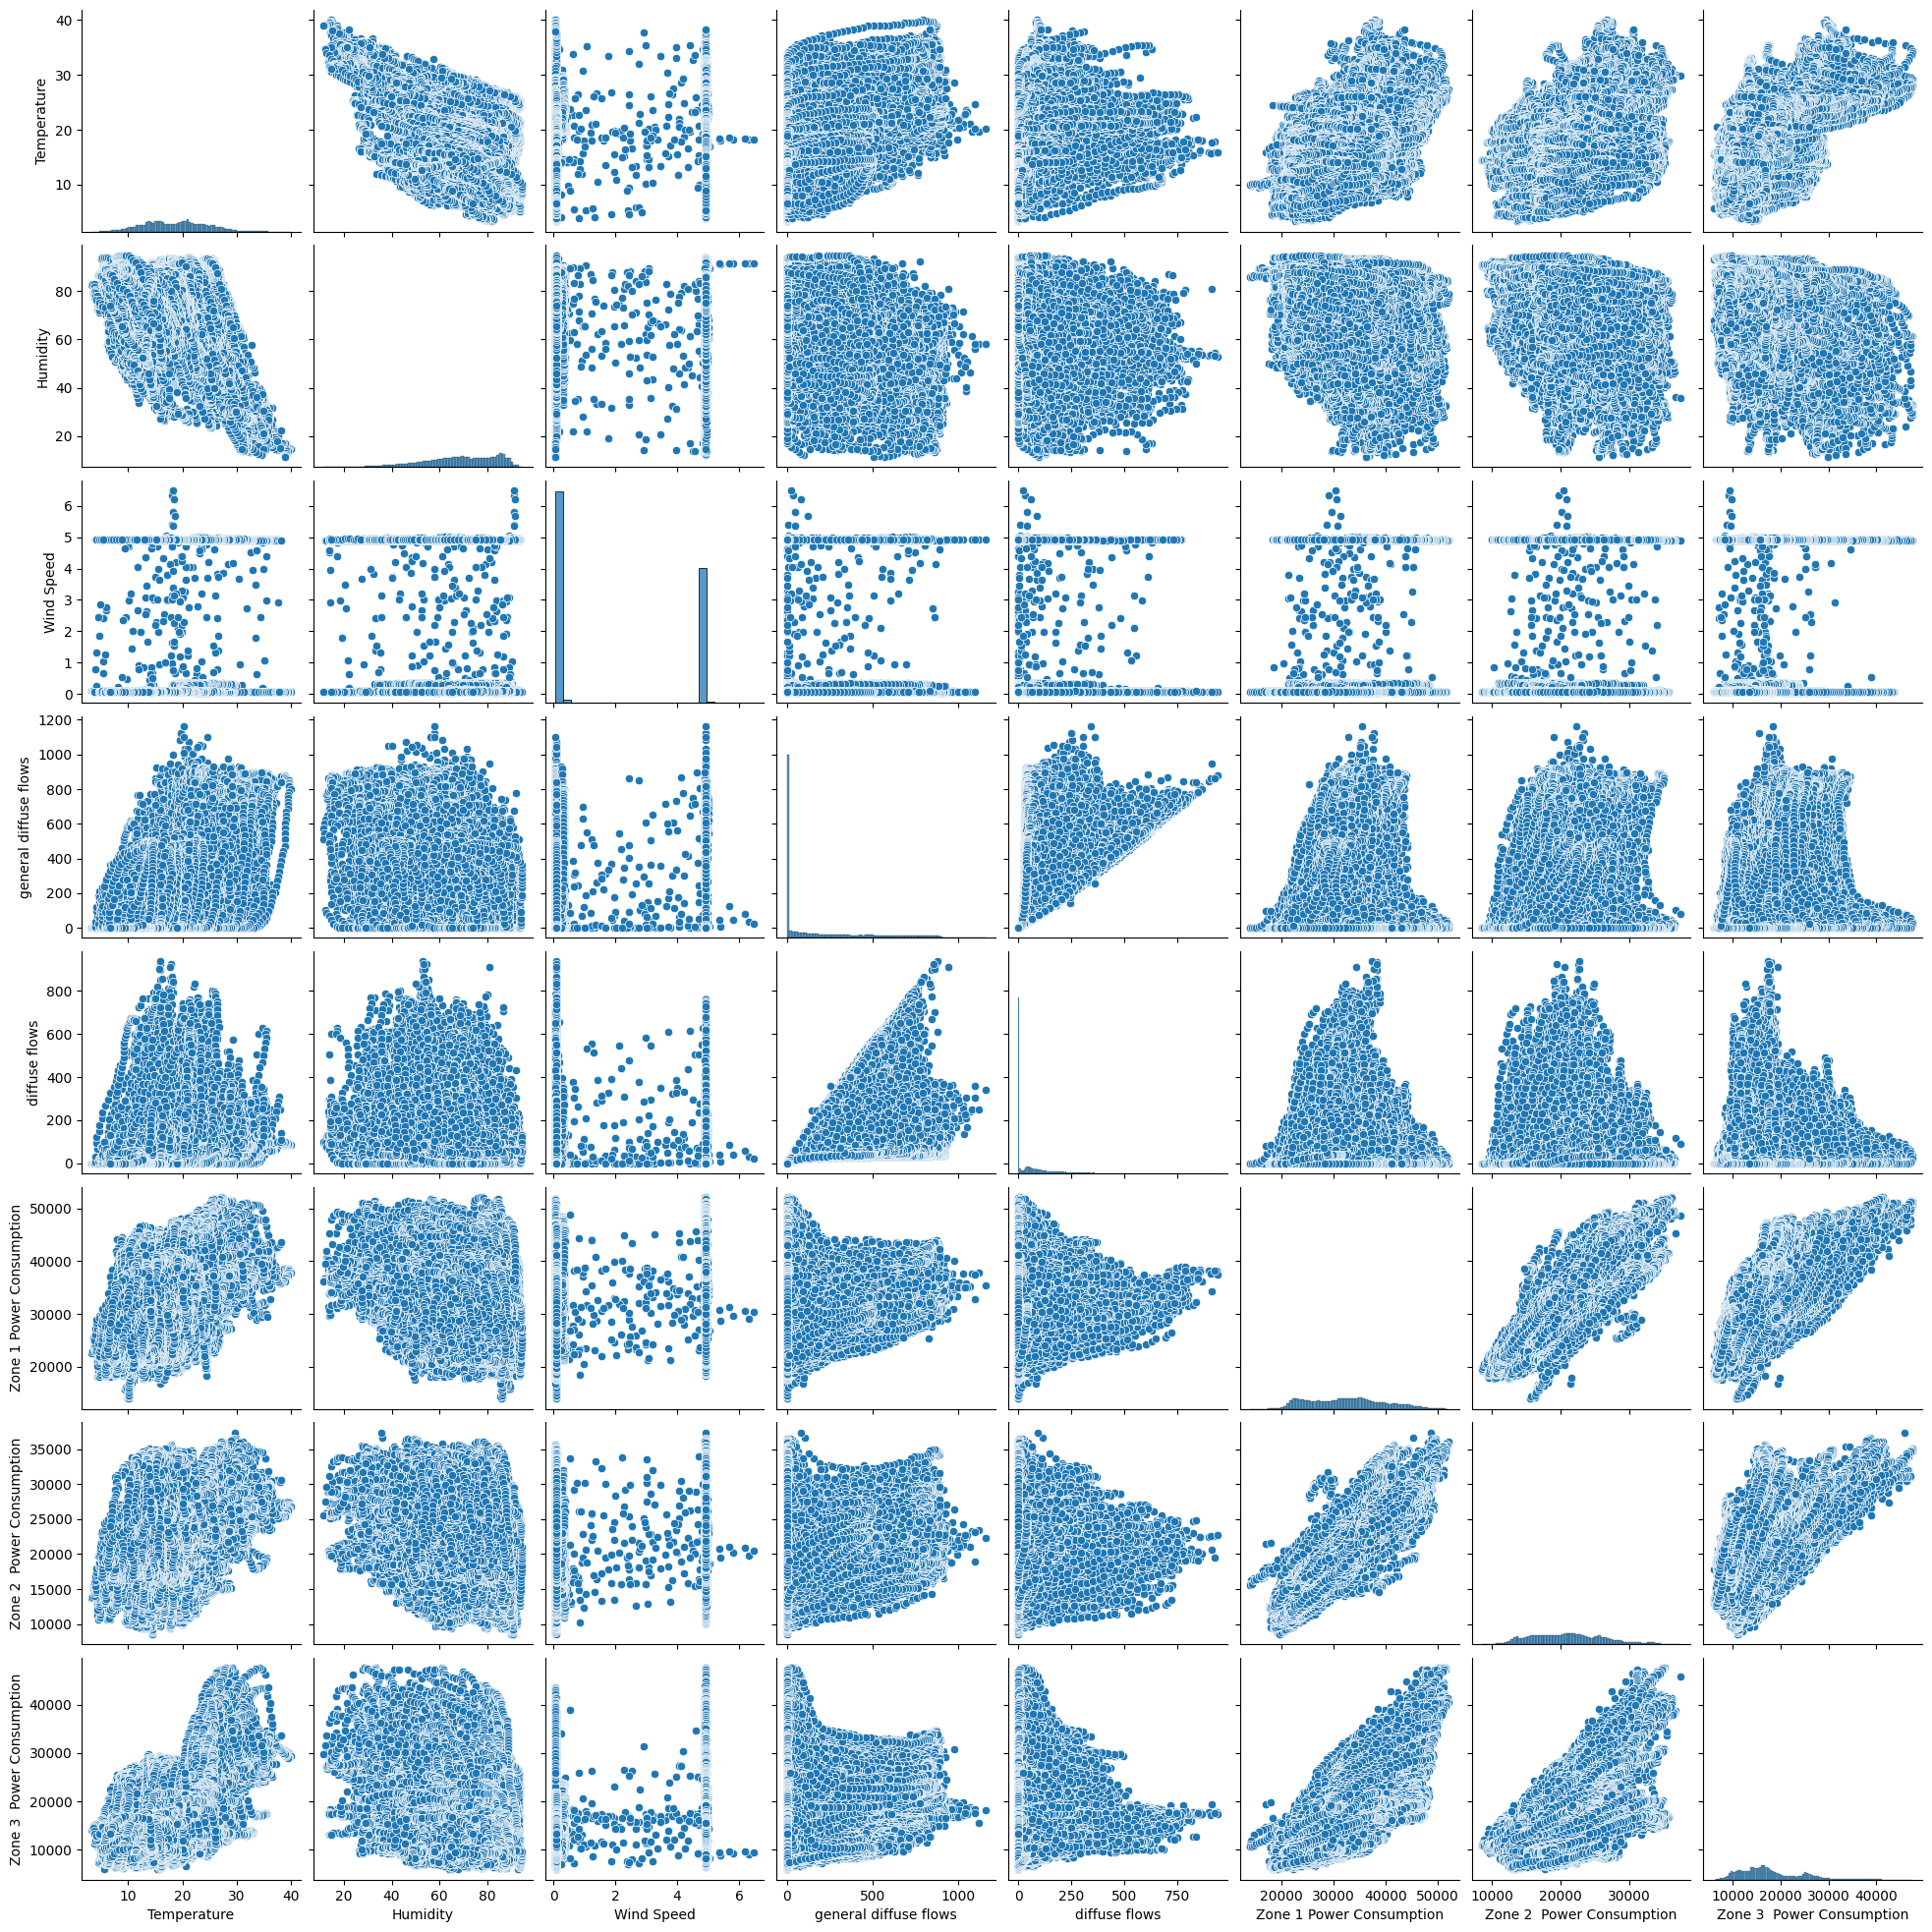

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.pairplot(numeric_df, diag_kind='hist')  # You can set diag_kind='kde' for KDE plots on the diagonal

plt.show()